In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')
df.head()

,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
person_id,,,,,,,,,,,,,,,,,,,,,
1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


# Analisis exploratorio (30%)
Aplica herramientas de estadística descriptiva para explorar en profundidad el conjunto de datos.
* Describir cada una de las variables (tipos de datos, distribución, valores atípicos, etc.)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
tabla_info = pd.DataFrame({
    'column name': df.columns,
    'dtype': df.dtypes.values,
    'valores nulos': df.isnull().sum().values,
    'valores no nulos': df.notnull().sum().values
})

print(tabla_info)
#tabla_info.to_excel("tabla_info.xlsx", index=False)

                    column name    dtype  valores nulos  valores no nulos
0                           age    int64              0            100000
1                        gender   object              0            100000
2                    occupation   object              0            100000
3                           bmi  float64              0            100000
4                       country   object              0            100000
5            sleep_duration_hrs  float64              0            100000
6           sleep_quality_score  float64              0            100000
7                rem_percentage  float64              0            100000
8         deep_sleep_percentage  float64              0            100000
9            sleep_latency_mins    int64              0            100000
10      wake_episodes_per_night    int64              0            100000
11       caffeine_mg_before_bed    int64              0            100000
12     alcohol_units_before_bed  float

In [9]:
df_describe = pd.DataFrame({
    'column name': df.describe().columns,
    'mean': df.describe().loc['mean'].values,
    'std': df.describe().loc['std'].values,
    'min': df.describe().loc['min'].values,
    '25%': df.describe().loc['25%'].values,
    '50%': df.describe().loc['50%'].values,
    '75%': df.describe().loc['75%'].values,
    'max': df.describe().loc['max'].values
})

#print(df_describe)
df_describe

,column name,mean,std,min,25%,50%,75%,max
0,age,34.706870,11.036373,18.0,26.00,33.00,42.00,69.0
1,bmi,26.289673,4.479578,16.0,23.20,26.30,29.30,45.0
2,sleep_duration_hrs,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
3,sleep_quality_score,4.871144,1.506517,1.0,3.80,4.90,6.00,10.0
4,rem_percentage,20.243968,3.411354,10.0,18.00,20.30,22.60,30.0
5,deep_sleep_percentage,20.253375,4.251096,5.0,17.40,20.30,23.20,30.0
6,sleep_latency_mins,19.836810,7.584343,1.0,14.00,19.00,25.00,58.0
7,wake_episodes_per_night,3.346610,1.920877,0.0,2.00,3.00,5.00,8.0
8,caffeine_mg_before_bed,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0
9,alcohol_units_before_bed,0.596800,1.059161,0.0,0.00,0.00,1.00,6.0


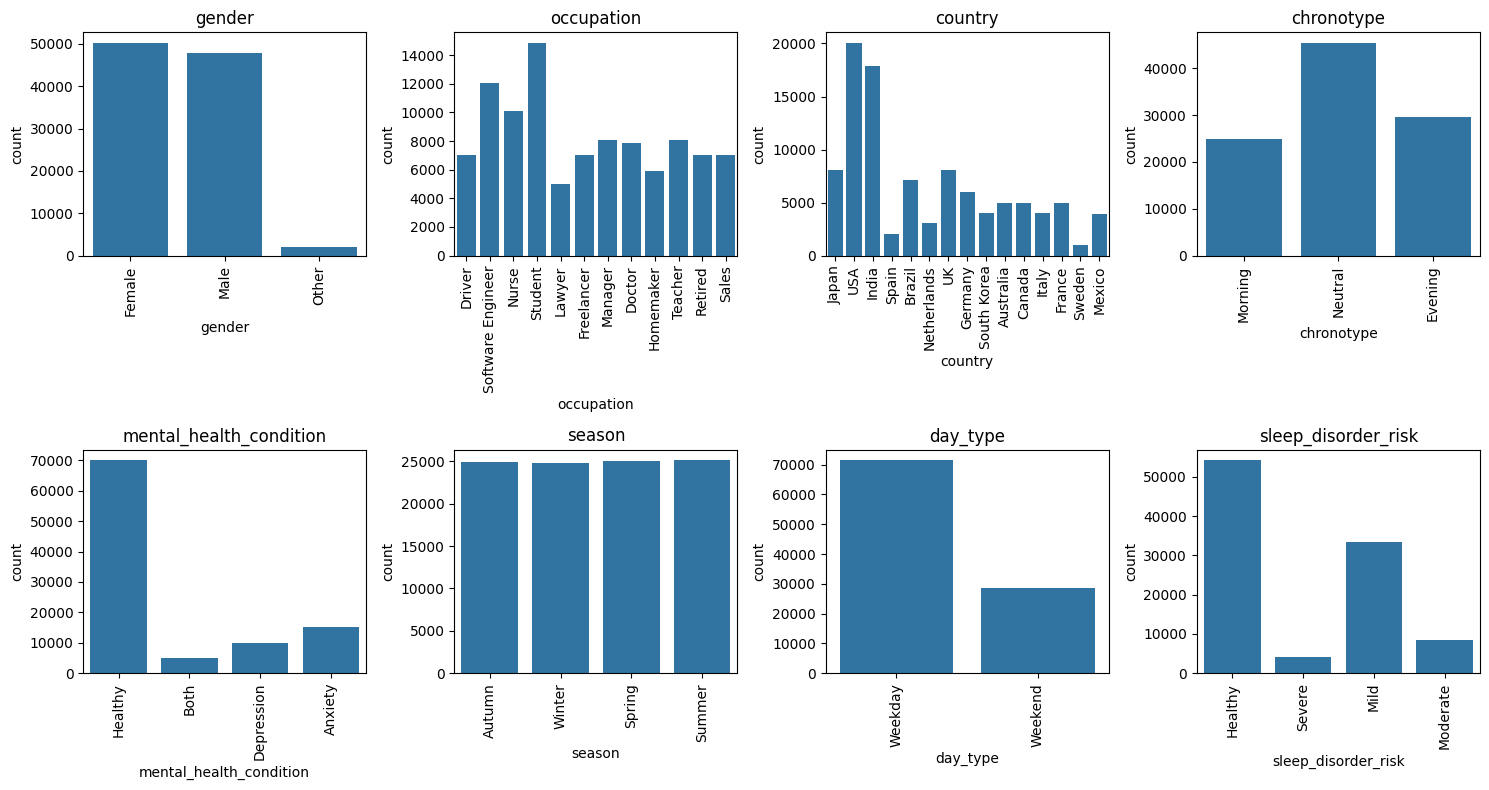

Columnas categóricas: Index(['gender', 'occupation', 'country', 'chronotype',
       'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk'],
      dtype='object')


In [ ]:
# analisis categoricos
categorical_cols = df.select_dtypes(include=["object"]).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 4, i + 1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=90)
    plt.title(col)

#plt.subplot(2, 2, 1)
#sns.countplot(x='gender', data=df)
#plt.title('Gender')

#plt.subplot(2, 2, 2)
#sns.countplot(x='occupation', data=df)
#plt.title('Occupation')
#plt.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
print("Columnas categóricas:", categorical_cols)

Columnas numéricas: Index(['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score',
       'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used',
       'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs',
       'cognitive_performance_score', 'felt_rested'],
      dtype='object')


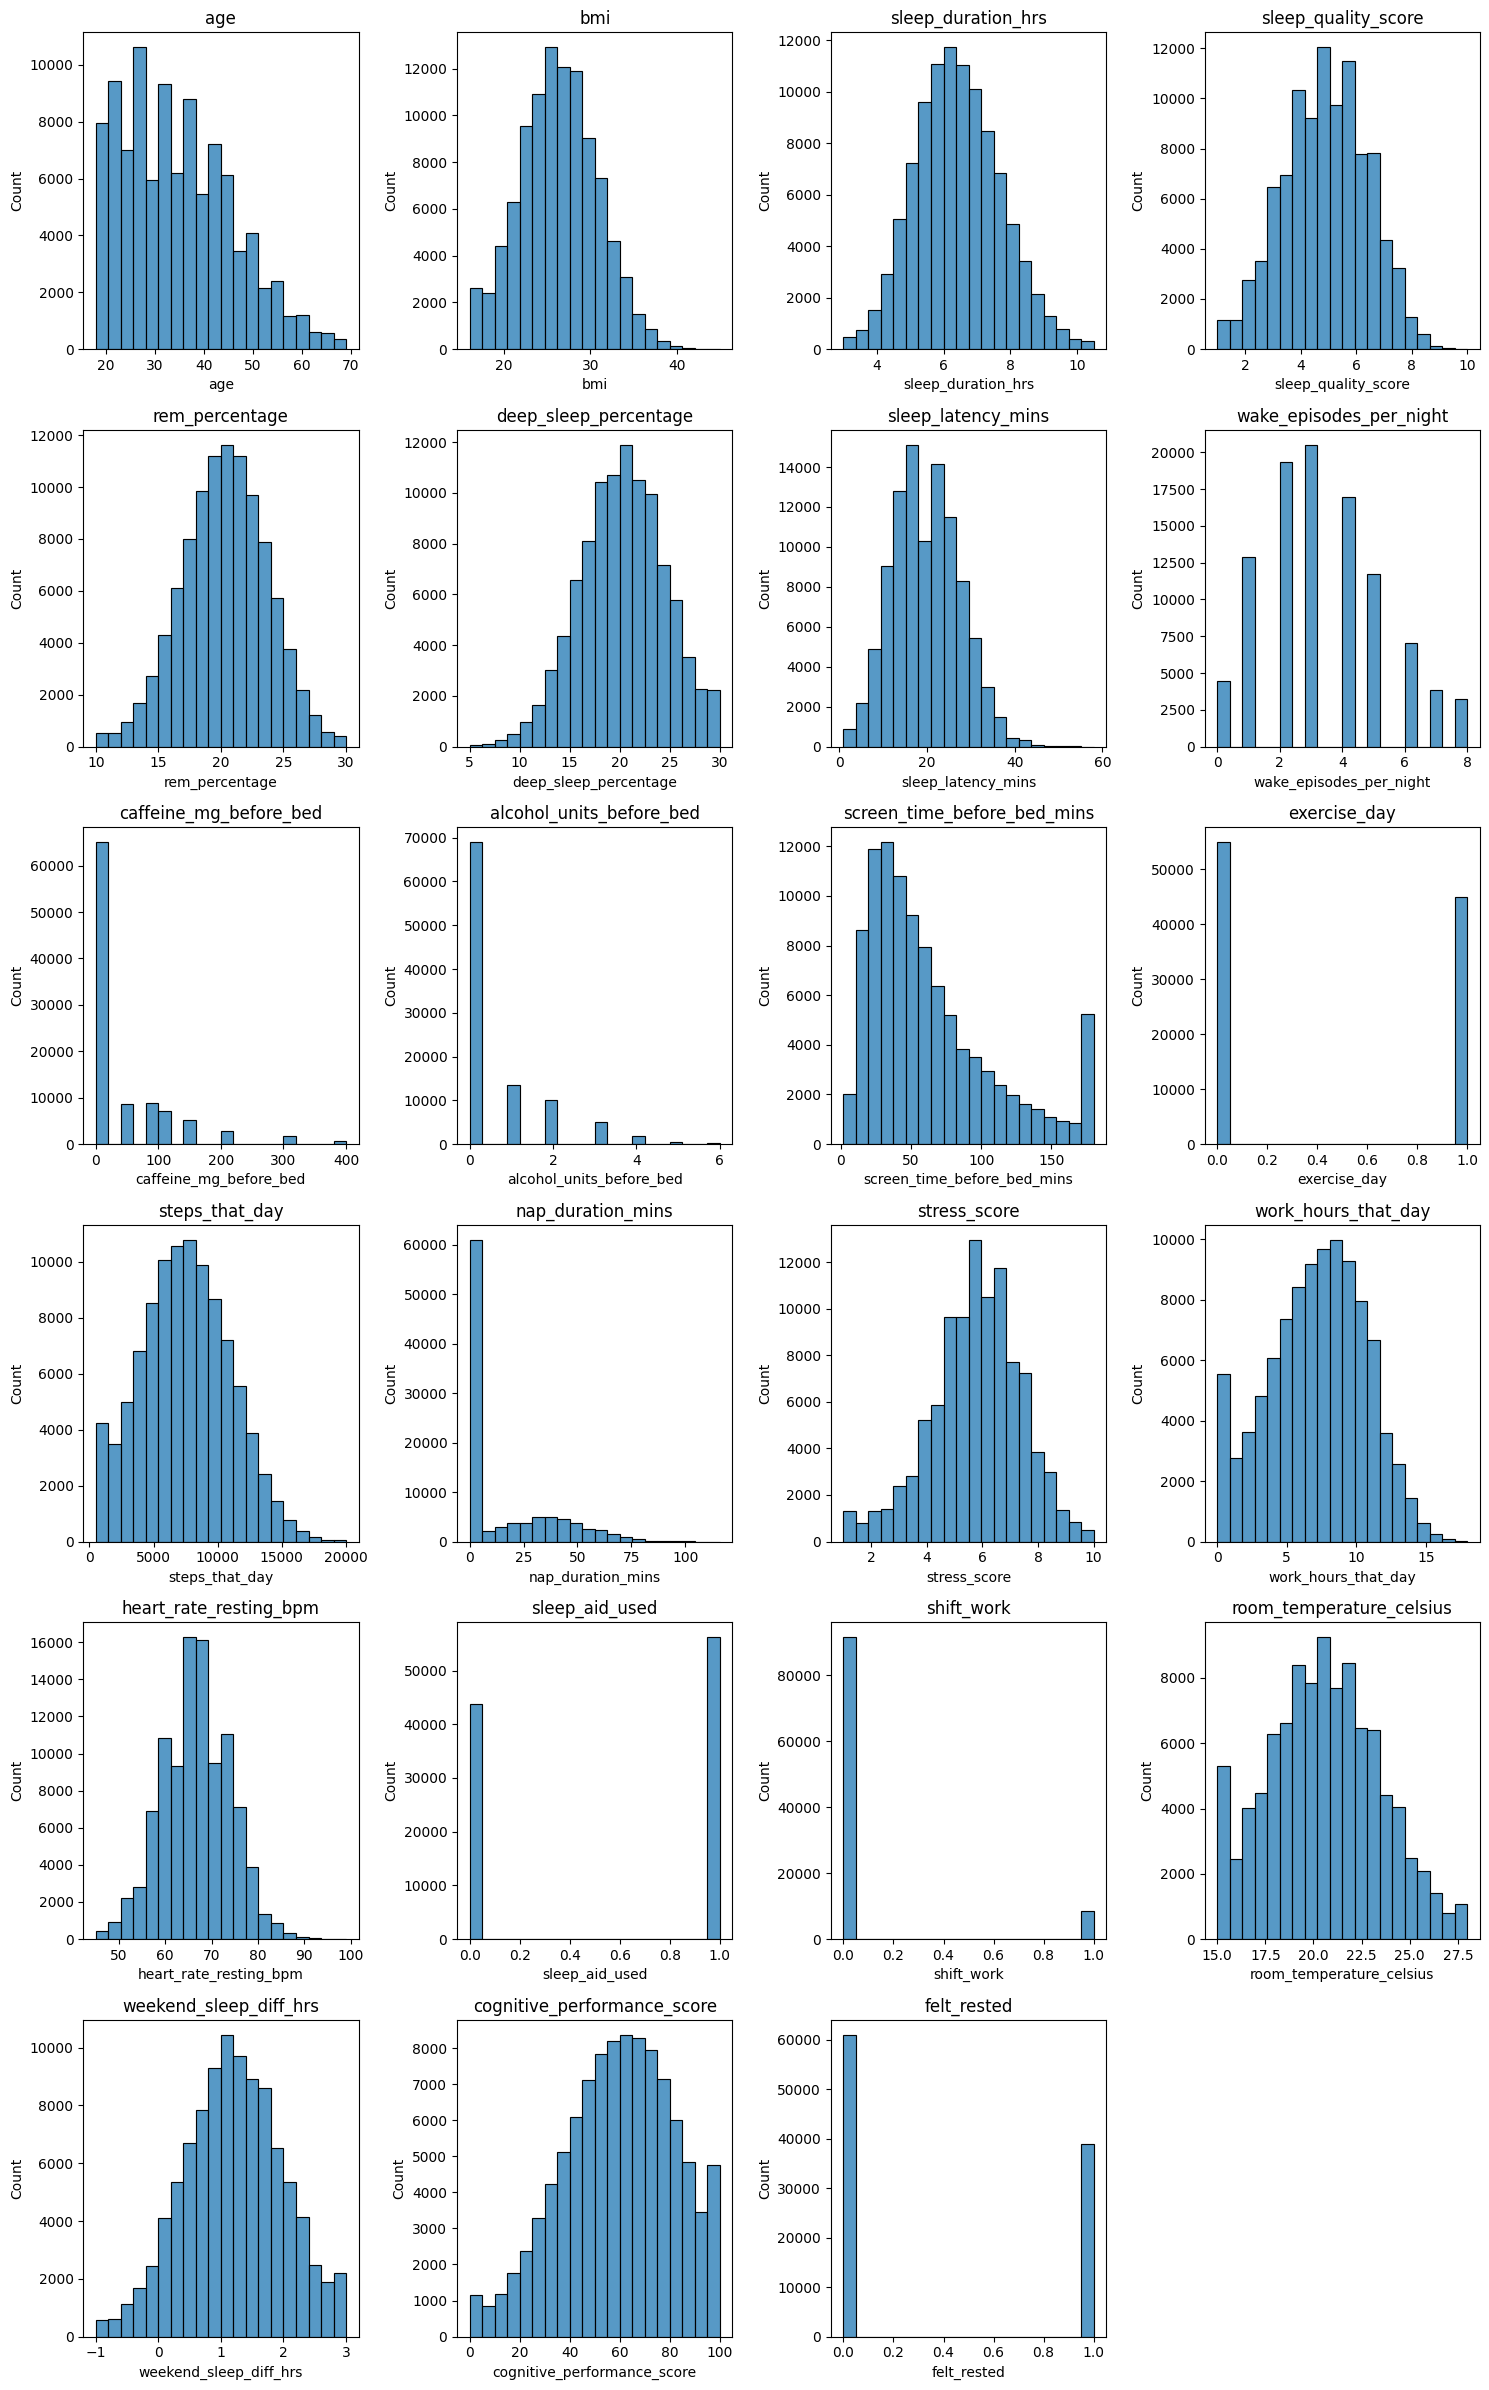

In [ ]:
# analisis numericos
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
print("Columnas numéricas:", numerical_cols)

plt.figure(figsize=(15, 24))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 4, i + 1)
    sns.histplot(x=col, data=df, bins=20)
    plt.xlabel(col)
    plt.title(col)

plt.tight_layout()
plt.show()

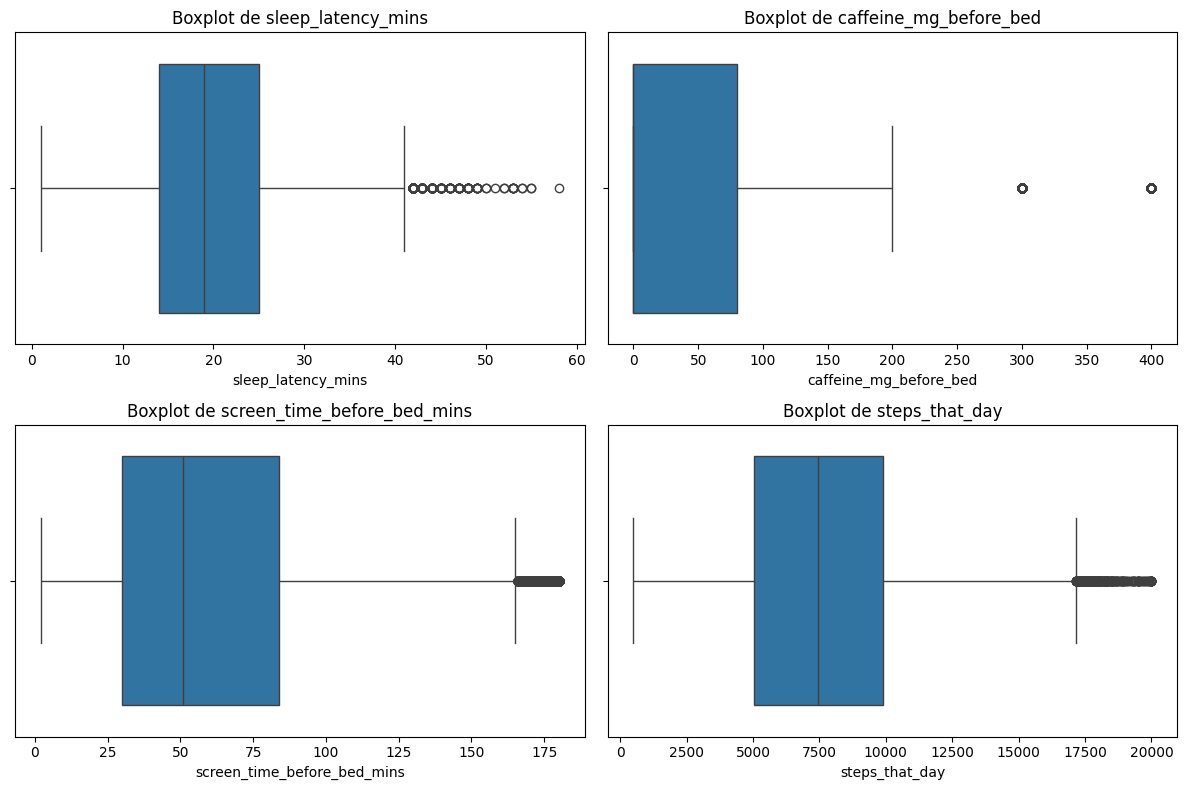

In [ ]:
columnas_para_boxplots = ['sleep_latency_mins', 'caffeine_mg_before_bed', 'screen_time_before_bed_mins', 'steps_that_day']
plt.figure(figsize=(12, 8))
for i, col in enumerate(columnas_para_boxplots):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

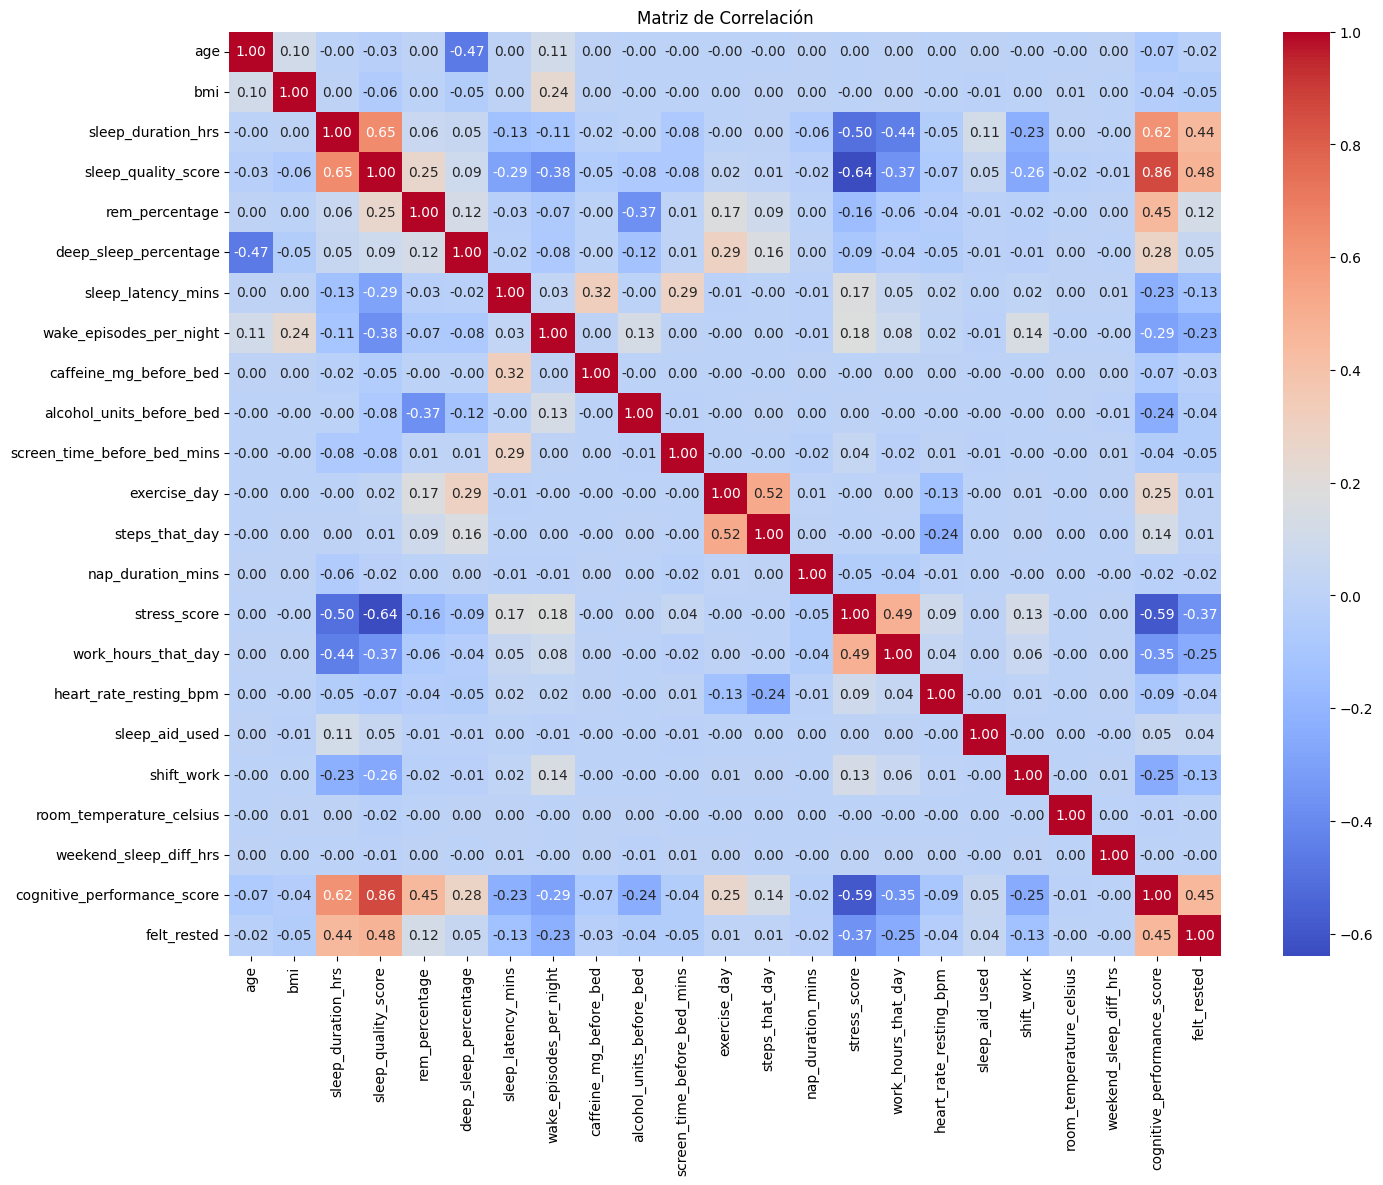

In [ ]:
plt.figure(figsize=(16, 12))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

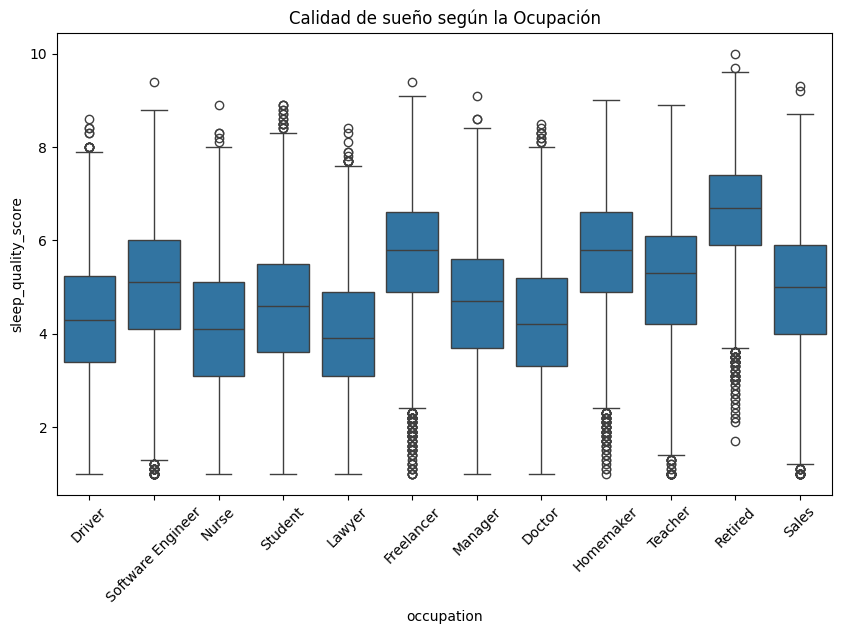

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='occupation', y='sleep_quality_score', data=df)
plt.xticks(rotation=45)
plt.title("Calidad de sueño según la Ocupación")
plt.show()

# Aplicación de Técnicas de Machine Learning (60%)
Aplica diferentes técnicas de aprendizaje automático al conjunto de datos, considerando tanto modelos supervisados como no supervisados, de acuerdo con la naturaleza del problema (clasificación, regresión o clustering). Esta parte es el eje central del proyecto y debe desarrollarse con especial profundidad

# NOTA DE VIK
Diana, en evaluacion del modelo es donde iria el cross validation, si ya quieres trabajar en eso mejor puedes hacer una funcion q saque las distintas metricas del modelo q se le meta?

## Clasificación

* Selección y Justificación del Modelo:

Al menos dos algoritmos distintos (por ejemplo: regresión logística, árbol de decisión, SVM, k-NN, redes neuronales, k-means, etc.) y justificar su elección con base en el tipo de datos y la tarea a resolver.

* Entrenamiento del Modelo:

Realizar el proceso completo de entrenamiento con los datos preparados. Al menos tres ejecuciones del modelo con diferentes particiones o semillas aleatorias para validar la estabilidad de los resultados.

* Evaluación del Modelo:

Para clasificación: accuracy, matriz de confusión, F1-score.

* Comparación de Resultados:

**Tabla comparativa** de los modelos utilizados y sus respectivas métricas.
Justificar cuál modelo es más adecuado para el problema abordado, con base en los resultados obtenidos y su coherencia con el contexto del conjunto de datos.

* Conclusiones Técnicas:

**Redactar** un apartado donde se analicen los hallazgos obtenidos a partir del modelo (o modelos) seleccionados, incluyendo limitaciones, posibles mejoras y recomendaciones para futuras versiones del análisis.

# NOTA DE VIK

Hay dos targets de clasificacion, felt_rested es binario y sleep_disorder_risk que es categorico (4 clases)

In [ ]:
X = pd.get_dummies(df.drop(['felt_rested', 'cognitive_performance_score',
                            'sleep_disorder_risk'], axis=1), drop_first=True)
y_bin = df['felt_rested']
y_reg = df['cognitive_performance_score']
y_class = df['sleep_disorder_risk']

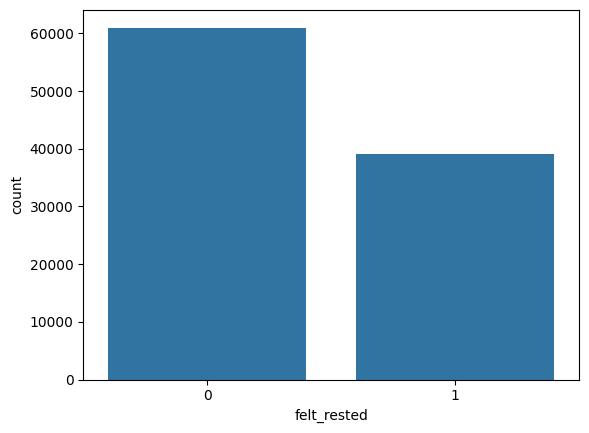

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='felt_rested', data=df)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

In [ ]:
# Clasificacion de felt_rested sin parametros o modificaciones

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic regression accuracy: 0.7087
KNN accuracy: 0.5633
Decision tree accuracy: 0.6643
Random forest accuracy: 0.7396


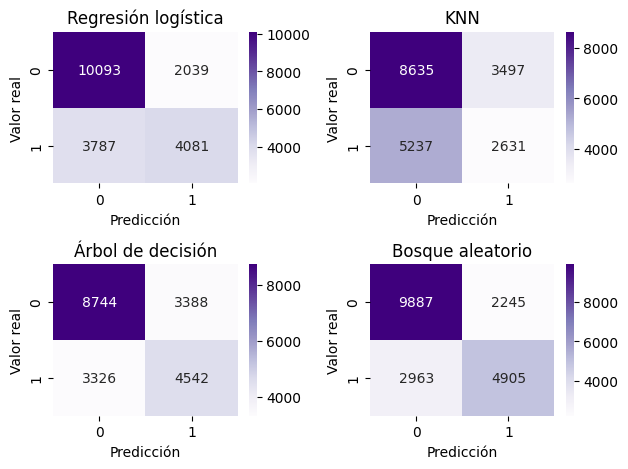

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

report_log = classification_report(y_test, y_pred_log, output_dict=True)
print(f'Logistic regression accuracy: {report_log['accuracy']}')

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print(f'KNN accuracy: {report_knn['accuracy']}')

report_tree = classification_report(y_test, y_pred_tree, output_dict=True)
print(f'Decision tree accuracy: {report_tree['accuracy']}')

report_forest = classification_report(y_test, y_pred_forest, output_dict=True)
print(f'Random forest accuracy: {report_forest['accuracy']}')

plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='.0f', cmap='Purples')
plt.title('Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='.0f', cmap='Purples')
plt.title('KNN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='.0f', cmap='Purples')
plt.title('Árbol de decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='.0f', cmap='Purples')
plt.title('Bosque aleatorio')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

tree_model = DecisionTreeClassifier()
tree_model.fit(X_train_scaled, y_train)

forest_model = RandomForestClassifier()
forest_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_tree = tree_model.predict(X_test_scaled)
y_pred_forest = forest_model.predict(X_test_scaled)

Logistic regression accuracy: 0.738
KNN accuracy: 0.6771
Decision tree accuracy: 0.6643
Random forest accuracy: 0.7422


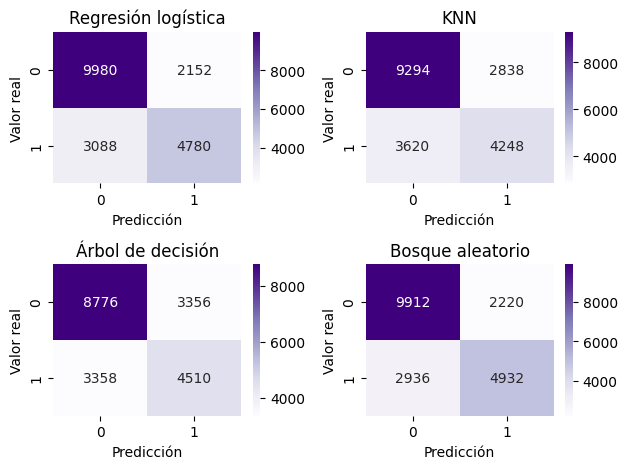

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

report_log = classification_report(y_test, y_pred_log, output_dict=True)
print(f'Logistic regression accuracy: {report_log['accuracy']}')

report_knn = classification_report(y_test, y_pred_knn, output_dict=True)
print(f'KNN accuracy: {report_knn['accuracy']}')

report_tree = classification_report(y_test, y_pred_tree, output_dict=True)
print(f'Decision tree accuracy: {report_tree['accuracy']}')

report_forest = classification_report(y_test, y_pred_forest, output_dict=True)
print(f'Random forest accuracy: {report_forest['accuracy']}')

plt.subplot(2, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='.0f', cmap='Purples')
plt.title('Regresión logística')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='.0f', cmap='Purples')
plt.title('KNN')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 3)
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='.0f', cmap='Purples')
plt.title('Árbol de decisión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.subplot(2, 2, 4)
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, fmt='.0f', cmap='Purples')
plt.title('Bosque aleatorio')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

DecisionTreeClassifier()

              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98     10892
        Mild       0.89      0.88      0.89      6673
    Moderate       0.56      0.59      0.58      1626
      Severe       0.71      0.70      0.71       809

    accuracy                           0.90     20000
   macro avg       0.78      0.79      0.79     20000
weighted avg       0.90      0.90      0.90     20000



<Axes: >

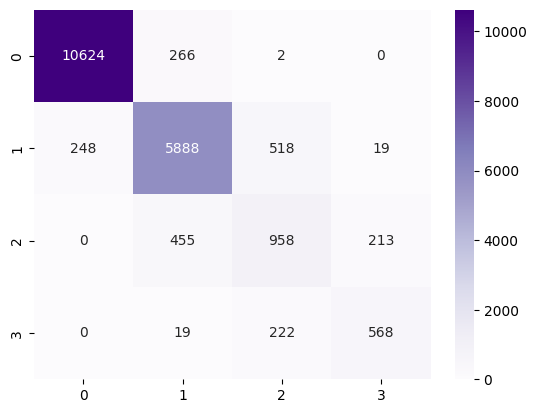

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.0f', cmap='Purples')

## Regresión

* Selección y Justificación del Modelo:

Elegir al menos dos algoritmos distintos (por ejemplo: SVM, redes neuronales, nose q mas pueda ir en regresion, etc.) y justificar su elección con base en el tipo de datos y la tarea a resolver.

* Entrenamiento del Modelo:

Realizar el proceso completo de entrenamiento con los datos preparados. Al menos tres ejecuciones del modelo con diferentes particiones o semillas aleatorias para validar la estabilidad de los resultados.

* Evaluación del Modelo:

Para regresión: MAE, RMSE, R².

* Comparación de Resultados:

**Tabla comparativa** de los modelos utilizados y sus respectivas métricas.
Justificar cuál modelo es más adecuado para el problema abordado, con base en los resultados obtenidos y su coherencia con el contexto del conjunto de datos.

* Conclusiones Técnicas:

**Redactar** un apartado donde se analicen los hallazgos obtenidos a partir del modelo (o modelos) seleccionados, incluyendo limitaciones, posibles mejoras y recomendaciones para futuras versiones del análisis.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred = lin_model.predict(X_test)

MSE: 49.51624612300319
R2: 0.8992385078929722
MAE: 5.529094293415574


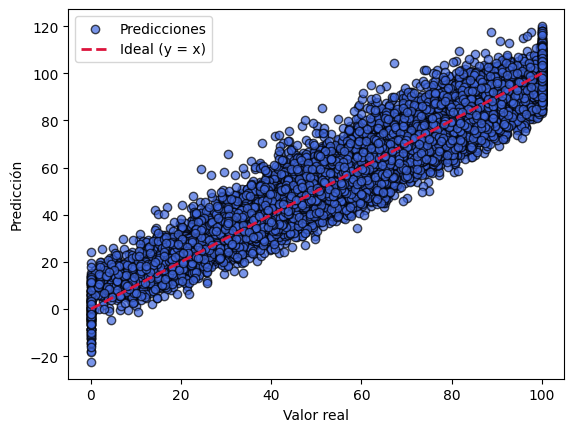

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'MSE: {mse}')
print(f'R2: {r2}')
print(f'MAE: {mae}')

plt.scatter(y_test, y_pred, color="royalblue", alpha=0.7, edgecolor="k", label="Predicciones")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="crimson", lw=2, linestyle="--", label="Ideal (y = x)")
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.legend()
plt.show()

## Clustering

Selección y Justificación del Modelo:

Elegir al menos dos algoritmos distintos (por ejemplo: redes neuronales, clustering k-means, idk q mas vaya con clustering, etc.) y justificar su elección con base en el tipo de datos y la tarea a resolver.

* Entrenamiento del Modelo:

Realizar el proceso completo de entrenamiento con los datos preparados. Al menos tres ejecuciones del modelo con diferentes particiones o semillas aleatorias para validar la estabilidad de los resultados.

* Evaluación del Modelo:

Para clustering: silueta, inercia, etc.

* Comparación de Resultados:

**Tabla comparativa** de los modelos utilizados y sus respectivas métricas.
Justificar cuál modelo es más adecuado para el problema abordado, con base en los resultados obtenidos y su coherencia con el contexto del conjunto de datos.

* Conclusiones Técnicas:

**Redactar** un apartado donde se analicen los hallazgos obtenidos a partir del modelo (o modelos) seleccionados, incluyendo limitaciones, posibles mejoras y recomendaciones para futuras versiones del análisis.

#Eleccion de los modelos de Clustering

**K-Means**: Es un modelo de clustering bastante comun y robusto, el cual nos ayuda a generar grupos por la distancia entre cada punto, generando clusters donde haya una mayor concentración de datos. Fue elegido para este dataset debido a su practicidad y bastante util como punto de partida para esta seccion

**Gaussian Mixture Model**: Es un modelo de clustering bastante flexible y rápido. Calcula la probabilidad de que cada dato aparezca en un grupo, generando así los clusters. Fue elegido para este dataset por su flexibilidad ante datos atípicos

In [ ]:
#Obtenemos de nuevo el dataframe
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df_kms = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')

#Ahora, escalamos el dataset y seleccionamos las columnas objetivo

columnas_deseadas = [
    "age",
    "bmi",
    "sleep_duration_hrs",
    "rem_percentage",
    "screen_time_before_bed_mins",
    "stress_score",
    'sleep_latency_mins',
    "room_temperature_celsius",
    "work_hours_that_day",
    "sleep_quality_score",
    "wake_episodes_per_night",
    'heart_rate_resting_bpm',
    'cognitive_performance_score'
]
X = df_kms[columnas_deseadas].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Fijamos a 3 clusters debido a los resultados obtenidos en el Silhouette Score del siguiente bloque
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

df_kms["cluster"] = kmeans.labels_

#Reducimos a 2 dimensiones para poder englobar todas nuestras variables en la tabla (y no tener que hacer un grafico
# de multiples dimensiones)
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_kms["PCA1"] = componentes[:, 0]
df_kms["PCA2"] = componentes[:, 1]

centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_kms, x="PCA1", y="PCA2", hue="cluster", palette="viridis", alpha=0.7
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroides",
)

# Detalles estéticos
plt.title(
    "Visualización de Clusters de Sueño (PCA 2D)", fontsize=14, fontweight="bold"
)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.legend(loc="upper right", title="Clusters")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [ ]:
#Verificamos que el kmeans sea correcto con Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

# Rango de valores de K a probar
range_n_clusters = range(2, 10)

silhouette_scores = []

for k in range_n_clusters:
    # Entrenar K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Calcular silhouette score
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.4f}")

# Graficar resultados
plt.figure(figsize=(8,5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Score para diferentes valores de K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [ ]:
#Seguna ejecucion de K-Means
#Obtenemos de nuevo el dataframe

#Fijamos a 3 clusters debido a los resultados obtenidos en el Silhouette Score del siguiente bloque
kmeans = KMeans(n_clusters=3, random_state=12)
kmeans.fit(X_scaled)

df_kms["cluster"] = kmeans.labels_

#Reducimos a 2 dimensiones para poder englobar todas nuestras variables en la tabla (y no tener que hacer un grafico
# de multiples dimensiones)
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_kms["PCA1"] = componentes[:, 0]
df_kms["PCA2"] = componentes[:, 1]

centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_kms, x="PCA1", y="PCA2", hue="cluster", palette="viridis", alpha=0.7
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroides",
)

# Detalles estéticos
plt.title(
    "Visualización de Clusters de Sueño (PCA 2D)", fontsize=14, fontweight="bold"
)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.legend(loc="upper right", title="Clusters")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

#Fijamos a 3 clusters debido a los resultados obtenidos en el Silhouette Score del siguiente bloque
kmeans = KMeans(n_clusters=3, random_state=5)
kmeans.fit(X_scaled)

df_kms["cluster"] = kmeans.labels_

#Reducimos a 2 dimensiones para poder englobar todas nuestras variables en la tabla (y no tener que hacer un grafico
# de multiples dimensiones)
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

df_kms["PCA1"] = componentes[:, 0]
df_kms["PCA2"] = componentes[:, 1]

centroides_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df_kms, x="PCA1", y="PCA2", hue="cluster", palette="viridis", alpha=0.7
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c="red",
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroides",
)

# Detalles estéticos
plt.title(
    "Visualización de Clusters de Sueño (PCA 2D)", fontsize=14, fontweight="bold"
)
plt.xlabel("Componente Principal 1", fontsize=12)
plt.ylabel("Componente Principal 2", fontsize=12)
plt.legend(loc="upper right", title="Clusters")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

In [ ]:
#Ahora hacemos clustering con Gaussian Mixture Model
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df_gmm = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')

columnas_deseadas = [
    "age",
    "bmi",
    "sleep_duration_hrs",
    "rem_percentage",
    "screen_time_before_bed_mins",
    "stress_score",
    'sleep_latency_mins',
    "room_temperature_celsius",
    "work_hours_that_day",
    "sleep_quality_score",
    "wake_episodes_per_night",
    'heart_rate_resting_bpm',
    'cognitive_performance_score'
]
X = df_gmm[columnas_deseadas].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 3 #Fijamos a 3 por el resultado obtenido en la tabla de resultados de abajo
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(X_scaled)

X["cluster"]      = gmm.predict(X_scaled)          # cluster asignado (0, 1, 2...)
X["prob_max"]     = gmm.predict_proba(X_scaled).max(axis=1)  # confianza de asignación
X["log_score"]    = gmm.score_samples(X_scaled)    # log-verosimilitud (outlier detection)

df_gmm1 = df_gmm.join(X[["cluster", "prob_max", "log_score"]], how="left")

#Ahora Comparamos los resultados desde k=2 hasta k=9 de la metrica bic (Bayesian Information Criterion)
# y aic (Akaike Information Criterion)
from sklearn.mixture import GaussianMixture
import numpy as np

resultados = []

for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    resultados.append({
        "k":   k,
        "bic": gmm.bic(X_scaled),   # menor = mejor
        "aic": gmm.aic(X_scaled),   # menor = mejor
        "log_likelihood": gmm.score(X_scaled)  # mayor = mejor, pero siempre sube
    })

df_res = pd.DataFrame(resultados)
print(tabulate(df_res, headers='keys', tablefmt="pretty"))

In [ ]:
#Ahora realizamos las siguientes 2 ejecuciones de GMM

n_clusters = 3 #Fijamos a 3 por el resultado obtenido en la tabla de resultados de abajo
gmm = GaussianMixture(n_components=n_clusters, random_state=56)
gmm.fit(X_scaled)

X["cluster"]      = gmm.predict(X_scaled)          # cluster asignado (0, 1, 2...)
X["prob_max"]     = gmm.predict_proba(X_scaled).max(axis=1)  # confianza de asignación
X["log_score"]    = gmm.score_samples(X_scaled)    # log-verosimilitud (outlier detection)

df_gmm2 = df_gmm.join(X[["cluster", "prob_max", "log_score"]], how="left")

n_clusters = 3 #Fijamos a 3 por el resultado obtenido en la tabla de resultados de abajo
gmm = GaussianMixture(n_components=n_clusters, random_state=6)
gmm.fit(X_scaled)

X["cluster"]      = gmm.predict(X_scaled)          # cluster asignado (0, 1, 2...)
X["prob_max"]     = gmm.predict_proba(X_scaled).max(axis=1)  # confianza de asignación
X["log_score"]    = gmm.score_samples(X_scaled)    # log-verosimilitud (outlier detection)

df_gmm3 = df_gmm.join(X[["cluster", "prob_max", "log_score"]], how="left")

#Comparamos con gmm1, gmm2 y gmm3
columnas_analisis = columnas_deseadas + ['cluster']
gmm1 = df_gmm1[columnas_analisis].groupby('cluster').mean()
gmm2 = df_gmm2[columnas_analisis].groupby('cluster').mean()
gmm3 = df_gmm3[columnas_analisis].groupby('cluster').mean()
print(tabulate(gmm1, headers='keys', tablefmt="pretty"))
print(tabulate(gmm2, headers='keys', tablefmt="pretty"))
print(tabulate(gmm3, headers='keys', tablefmt="pretty"))

Podemos observar que los resultados se mantienen entre cada ejecucion distinta de GMM, el unico cambio es en el orden de los datos

In [ ]:
#Mostramos una tabla por mada modelo utilizado
from tabulate import tabulate
columnas_analisis = columnas_deseadas + ['cluster']

tabla_promedios_gmm = df_gmm1[columnas_analisis].groupby('cluster').mean()
tabla_promedios_kms = df_kms[columnas_analisis].groupby('cluster').mean()

print(tabulate(tabla_promedios_gmm, headers='keys', tablefmt="pretty"))
print(tabulate(tabla_promedios_kms, headers='keys', tablefmt="pretty"))

Con las tablas anteriores, podemos observar que, aunque los clusteres comparten edad, imc, porcentaje rem, temperatura promedio y latidos por minuto promedio similares, notamos que el primer grupo suele tener un horario de sueño estandar para un adulto, con un nivel de estres medio y y una calidad de sueño descente, mientras que el segundo grupo que duerme mas horas, suele tener una mejor calidad de sueño y suele tener una menor cantidad de estres. Por ultimo, el tercer grupo que duerme menos horas y trabaja mas horas, suele tener una mayor cantidad de estrés

# dianamamada

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import preprocessing
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [ ]:
#instancia de label encoder para convertir las variables categoricas a numericas
label_encoder = preprocessing.LabelEncoder()
dataD= df.copy().drop(['felt_rested', 'cognitive_performance_score','sleep_disorder_risk'], axis=1)
for columna in dataD.select_dtypes(include=["object"]).columns:
    dataD[columna] = label_encoder.fit_transform(dataD[columna])

y_d= df['sleep_disorder_risk']

In [ ]:
dataD.head()

In [ ]:
X_trainD, X_testD, y_trainD, y_testD = train_test_split(dataD, y_d, test_size=0.2, random_state=42)

pipeline=Pipeline([('escalar', StandardScaler()),('lr',LogisticRegression())])

# hiperparametros del pipeline y ajustar GridSearchCV
hiperparametros= [
    {'lr': [RandomForestClassifier()],
     'lr__n_estimators': [100, 200, 300],
     'lr__max_depth': [5, 10, 15, 30]},
    {'lr': [SVC()],
     'lr__kernel': ['sigmoid', 'rbf'],
     'lr__C': [0.01, 0.1, 1, 10]},
    {'lr': [LogisticRegression(max_iter=1000)],
     'lr__solver': ['liblinear', 'lbfgs'],
     'lr__C': [0.01, 0.1, 1, 10]},
    {'lr': [KNeighborsClassifier()],
     'lr__n_neighbors': [3, 5, 7, 9]},
    {'lr': [GradientBoostingClassifier()],
     'lr__n_estimators': [100, 200, 300, 400],
     'lr__learning_rate': [0.01, 0.1, 1]}
]

gs = GridSearchCV(pipeline,hiperparametros, cv=7)
gs.fit(X_trainD, y_trainD)

mejorModelo= gs.best_estimator_

modelos = [
    ('Random Forest', RandomForestClassifier()),
    ('SVM', SVC()),
    ('Logistic Regression', LogisticRegression()),
    ('KNN', KNeighborsClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier())
]

accuracy_scores = []
for n,m in modelos:
    pipeline = Pipeline([('escalar', StandardScaler()),('lr',m)])

    
    pipeline.fit(X_trainD, y_trainD)
    y_pred = pipeline.predict(X_test)
    precision = accuracy_score(y_test, y_pred)
    accuracy_scores.append(precision)